# 07 · 3D scenes, extrusion, and time

**Mission:** export data-driven extrusions and a time-aware CZML route. Allow 35 minutes. Prerequisite: Lab 03.

**Run:** choose the Python (Pyodide) kernel in JupyterLite, then Run → Run All Cells. First use downloads Matplotlib. All training data are **SYNTHETIC** unless explicitly labeled LIVE. Downloads appear below and in `exports/`; the browser filesystem is separate from your computer. Each lab runs independently.

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("matplotlib")
import json, math
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from worldview_lab import (load, export, map_layer, chart_style, haversine_km,
    wilson_interval, shortest_times, freshness, normalize_quakes,
    validate_geojson, brief_request, validate_brief)
chart_style()

## Make the third dimension explicit

The Cesium scene uses a WGS 84 ellipsoid, no terrain service or ion token. District height is `14-day cases per 100,000 × 5 metres`. This is **visual encoding**, not building height, elevation, flood depth, or airspace guidance. The scene provides 3D, 2D, and Columbus view, a day slider, a rate legend, and a separate animated supply-flight clock.

In [2]:
districts=load('districts.geojson');czml=load('response.czml')
for f in districts['features']:
    f['properties']['height_m']=f['properties']['rate_per_100k']*5
export('extruded-districts.geojson',districts)
export('supply-flight.czml',czml)
display({'text/html':'<iframe title="WorldView Cesium scene" src="https://jltobias.github.io/JupyterLite-WorldView/scenes/" width="100%" height="700"></iframe>'},raw=True)

## Scene lab

1. Open the [scene in a full tab](https://jltobias.github.io/JupyterLite-WorldView/scenes/).
2. Switch 3D → 2D → Columbus and compare occlusion.
3. Move the outbreak day slider from 1 to 14. Watch cumulative heights and labels.
4. Play the **supply flight** with Cesium’s animation control; scrub its one-hour timeline.
5. Import your GeoJSON export. To use edited CZML, replace `content/data/response.czml` in a local checkout and rebuild; the public UI imports GeoJSON only.

**Checkpoint:** the flight time (September 14, 12:00–13:00 UTC) and outbreak onset-day slider are different time dimensions. Camera tilt does not change the underlying numerical values.

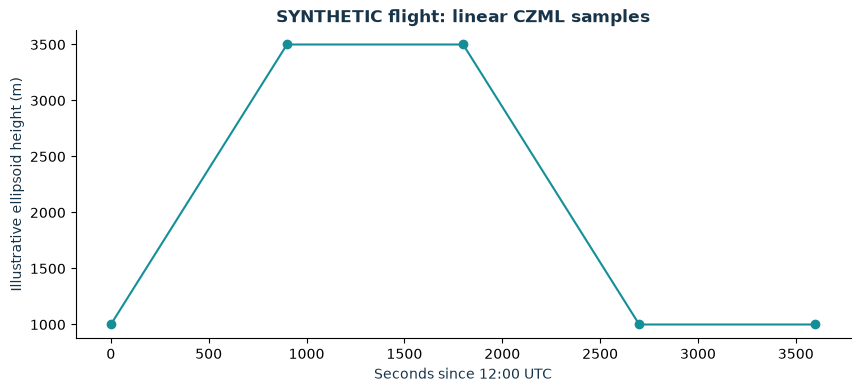

In [3]:
samples=czml[1]['position']['cartographicDegrees']
fig,ax=plt.subplots();ax.plot(samples[0::4],samples[3::4],'o-');ax.set(xlabel='Seconds since 12:00 UTC',ylabel='Illustrative ellipsoid height (m)',title='SYNTHETIC flight: linear CZML samples');plt.show()

## Use in the original World View

The repository’s `integrations/worldview/NotebookLayer.tsx` adapter mounts a Cesium data source inside the upstream Resium viewer. Follow the integration guide to load the same GeoJSON/CZML in a separate checkout of the original application. World View’s private API integrations remain separate services.

**Astra prompt:** “Review the scene screenshot and height definition. Explain three perception risks and suggest an alternative 2D view. Use the data table for exact values rather than measuring bars in the screenshot.”

## Sources and attribution

[Cesium Viewer](https://cesium.com/learn/cesiumjs/ref-doc/Viewer.html), [GeoJsonDataSource](https://cesium.com/learn/cesiumjs/ref-doc/GeoJsonDataSource.html), and [CzmlDataSource](https://cesium.com/learn/cesiumjs/ref-doc/CzmlDataSource.html) document the supported rendering APIs.

World View inspiration: [Kevin (Khoa) To, MIT](https://github.com/kevtoe/worldview). Original lab code, figures, and synthetic fixtures: JupyterLite WorldView contributors, MIT. See the [book references](https://jltobias.github.io/JupyterLite-WorldView/book/references.html) and repository notices for dependency and service terms.